# Chapter 12 Exercises: Unsupervised Learning
**Questions 8 and 13**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy import stats
import statsmodels.api as sm

## Question 8

*In Section 12.2.3, a formula for calculating PVE (Proportion of Variance Explained) was given in Equation 12.10. We also saw that the PVE can be obtained using the `explained_variance_ratio_` attribute of a fitted `PCA()` estimator.*

*On the USArrests data, calculate PVE in two ways:*
- *(a) Using the `explained_variance_ratio_` output of the fitted `PCA()` estimator.*
- *(b) By applying Equation 12.10 directly, using the loadings stored in the `components_` attribute.*

*These two approaches should give the same results.*

In [2]:
USArrests = sm.datasets.get_rdataset('USArrests').data
print(USArrests.shape)
USArrests.head()

(50, 4)


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


### Part (a): PVE via `explained_variance_ratio_`

As in Section 12.2.3, the variables must be standardized (mean zero, standard deviation one) before PCA, since the raw features are on very different scales (e.g. `Assault` is in the hundreds while `Rape` and `Murder` are much smaller).

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(USArrests)

pca = PCA()
pca.fit(X_scaled)

pve_a = pca.explained_variance_ratio_
print("PVE (method a, explained_variance_ratio_):")
print(pve_a)

PVE (method a, explained_variance_ratio_):
[0.62006039 0.24744129 0.0891408  0.04335752]


### Part (b): PVE via Equation 12.10 directly

Equation 12.10 defines the PVE of the $m$-th principal component as:

$$\text{PVE}_m = \dfrac{\sum_{i=1}^{n}\left(\sum_{j=1}^{p}\phi_{jm}x_{ij}\right)^2}{\sum_{j=1}^{p}\sum_{i=1}^{n}x_{ij}^2}$$

The numerator is the sum of squared principal component scores for component $m$ (since $z_{im} = \sum_j \phi_{jm}x_{ij}$), and the denominator is the total variance in the (centered/scaled) data. The loadings $\phi_{jm}$ come from `pca.components_`, and the same standardized data (`X_scaled`) used in part (a) must be used here for the two approaches to agree.

In [4]:
loadings = pca.components_
scores = X_scaled @ loadings.T

numerator = (scores ** 2).sum(axis=0)
denominator = (X_scaled ** 2).sum()
pve_b = numerator / denominator

print("PVE (method b, Equation 12.10):")
print(pve_b)

print("\nDo the two methods match?", np.allclose(pve_a, pve_b))

PVE (method b, Equation 12.10):
[0.62006039 0.24744129 0.0891408  0.04335752]

Do the two methods match? True


In [5]:
pve_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pve_a))],
    'PVE (method a)': pve_a,
    'PVE (method b)': pve_b
})
pve_table

,Component,PVE (method a),PVE (method b)
0,PC1,0.620060,0.620060
1,PC2,0.247441,0.247441
2,PC3,0.089141,0.089141
3,PC4,0.043358,0.043358


**Conclusion:** Both methods give identical results (confirmed by `np.allclose`). This makes sense, since `explained_variance_ratio_` is computed internally by scikit-learn using essentially the same calculation as Equation 12.10 — the proportion of total variance captured by projecting the data onto each principal component direction. The first principal component alone explains about 62% of the total variance in the USArrests data, and the first two together explain about 87%.

---
## Question 13

*On the book website, www.statlearning.com, there is a gene expression data set (`Ch12Ex13.csv`) that consists of 40 tissue samples with measurements on 1,000 genes. The first 20 samples are from healthy patients, while the second 20 are from a diseased group.*

*(a) Load in the data using `pd.read_csv()`. You will need to select `header = None`.*

*(b) Apply hierarchical clustering to the samples using correlation-based distance, and plot the dendrogram. Do the genes separate the samples into the two groups? Do your results depend on the type of linkage used?*

*(c) Your collaborator wants to know which genes differ the most across the two groups. Suggest a way to answer this question, and apply it here.*

### Part (a): Load the data

In [6]:
data = pd.read_csv('Ch12Ex13.csv', header=None)
data.columns = [f'H{i}' for i in range(1, 21)] + [f'D{i}' for i in range(1, 21)]

print(data.shape)
data.iloc[:5, :6]

(1000, 40)


,H1,H2,H3,H4,H5,H6
0,-0.961933,0.441803,-0.975005,1.417504,0.818815,0.316294
1,-0.292526,-1.139267,0.195837,-1.281121,-0.251439,2.511997
2,0.258788,-0.972845,0.588486,-0.800258,-1.820398,-2.058924
3,-1.152132,-2.213168,-0.861525,0.630925,0.951772,-1.165724
4,0.195783,0.593306,0.282992,0.247147,1.978668,-0.871018


The data has 1,000 rows (genes) and 40 columns (samples) — the first 20 columns (`H1`-`H20`) are healthy patients, and the last 20 (`D1`-`D20`) are from the diseased group, matching the assignment description exactly.

### Part (b): Hierarchical clustering with correlation-based distance

Correlation-based distance is computed between the **samples** (columns), since we want to cluster the 40 tissue samples, not the 1,000 genes. The distance between two samples is $1 - r$, where $r$ is the Pearson correlation between their expression profiles across all 1,000 genes.

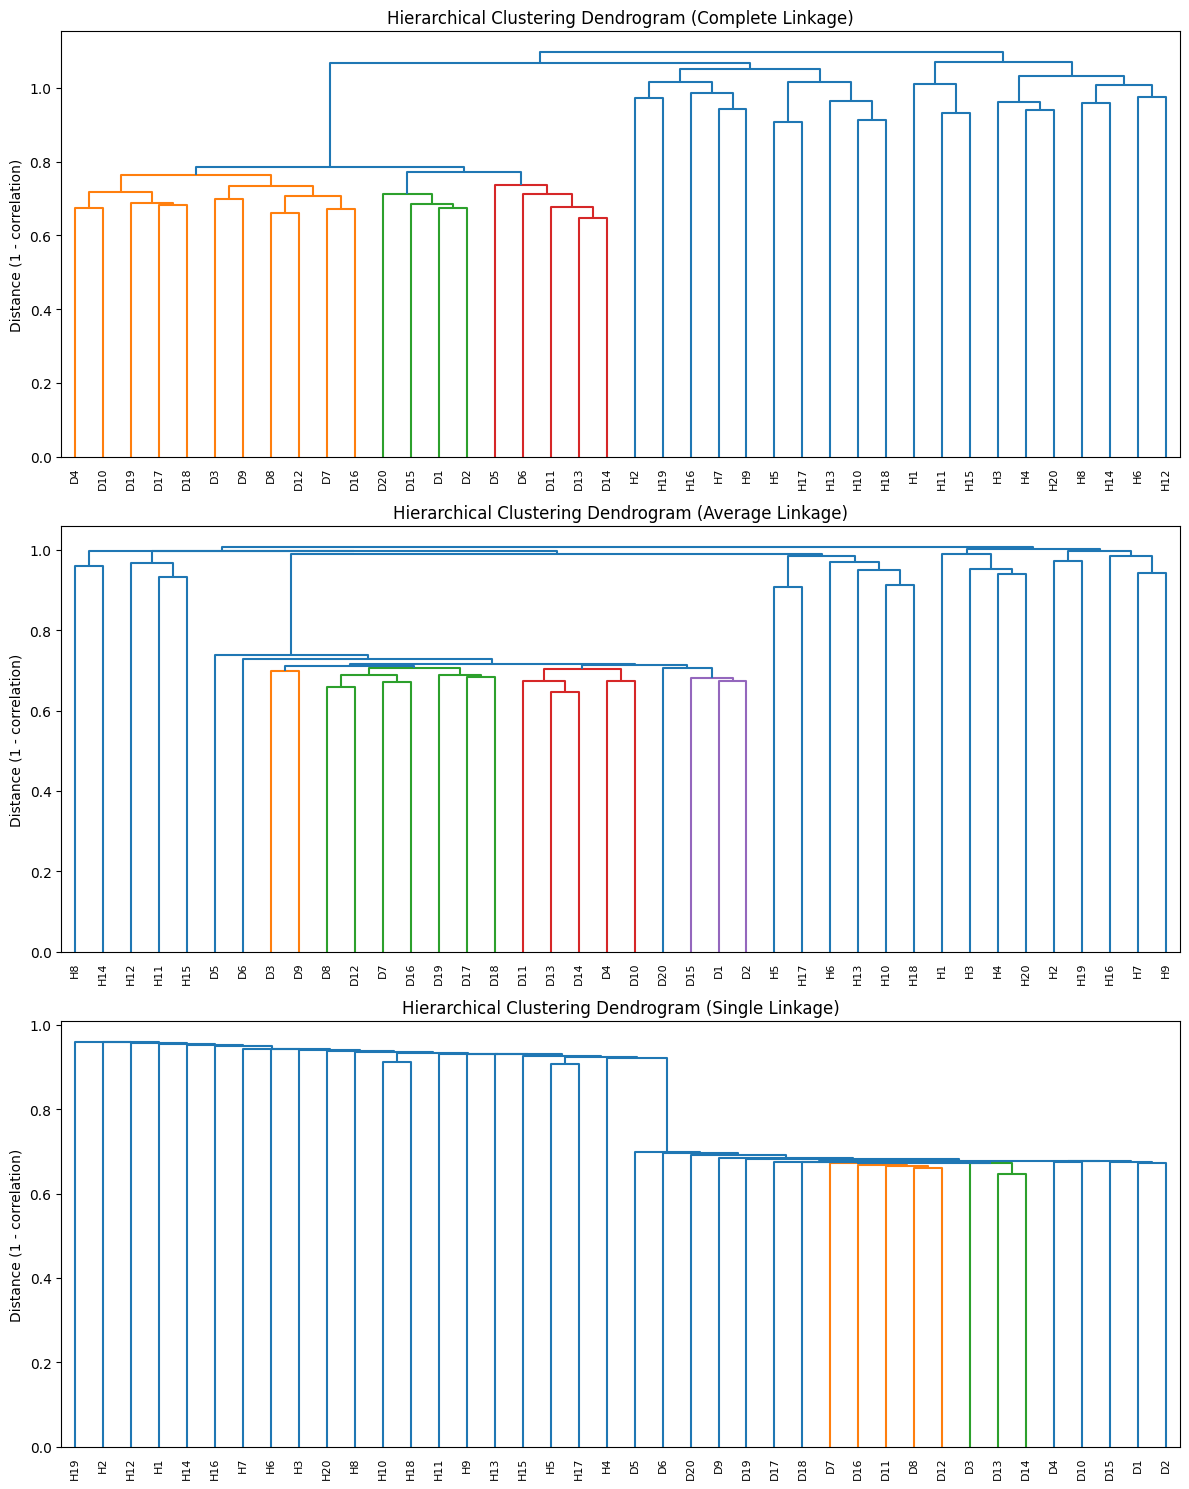

In [7]:
corr = data.corr()
dist = 1 - corr
condensed_dist = squareform(dist.values, checks=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for ax, method in zip(axes, ['complete', 'average', 'single']):
    Z = linkage(condensed_dist, method=method)
    dendrogram(Z, labels=data.columns.tolist(), ax=ax, leaf_rotation=90)
    ax.set_title(f'Hierarchical Clustering Dendrogram ({method.capitalize()} Linkage)')
    ax.set_ylabel('Distance (1 - correlation)')

plt.tight_layout()
plt.savefig('dendrograms.png', dpi=150)
plt.show()

In [8]:
true_labels = ['H'] * 20 + ['D'] * 20

for method in ['complete', 'average', 'single']:
    Z = linkage(condensed_dist, method=method)
    clusters = fcluster(Z, t=2, criterion='maxclust')
    ct = pd.crosstab(pd.Series(true_labels, name='True group'), pd.Series(clusters, name='Cluster'))
    print(f"\n--- {method.capitalize()} linkage: cluster assignment vs true group ---")
    print(ct)


--- Complete linkage: cluster assignment vs true group ---
Cluster      1   2
True group        
D           20   0
H           10  10

--- Average linkage: cluster assignment vs true group ---
Cluster      1  2
True group       
D           20  0
H           11  9

--- Single linkage: cluster assignment vs true group ---
Cluster      1  2
True group       
D           20  0
H           19  1


**Do the genes separate the samples into the two groups?** Only partially, and the answer clearly depends on the linkage method used:

- **Complete linkage** and **average linkage** both identify a distinct sub-cluster made up entirely of healthy (`H`) samples, but the remaining healthy samples get grouped together with all 20 diseased samples in the other cluster — so the split is not a clean 20-vs-20 separation matching the true healthy/diseased labels.
- **Single linkage** produces a highly degenerate result: nearly all 40 samples fall into one giant cluster, with only a single outlier sample splitting off on its own. This is the classic "chaining" problem associated with single linkage — it tends to peel off one point at a time rather than forming balanced, meaningful groups.

**Do the results depend on the type of linkage used?** Yes, substantially. Complete and average linkage give broadly similar (though still imperfect) partial separations, while single linkage fails to recover any meaningful two-group structure at all. This illustrates a general property of hierarchical clustering: the choice of linkage can change the resulting cluster structure considerably, especially for noisy, high-dimensional data like gene expression measurements.

### Part (c): Which genes differ the most between the two groups?

A natural way to answer this is to run a **two-sample t-test** for each of the 1,000 genes, comparing its expression values in the diseased group against the healthy group. Genes with the largest absolute t-statistic (equivalently, the smallest p-value) show the strongest evidence of a mean difference between the two groups, and are the best candidates for genes that "differ the most."

(This is essentially the idea behind multiple testing, covered in Chapter 13 — with 1,000 simultaneous tests, some caution about false positives would be warranted in a rigorous analysis, but for the purpose of ranking genes by evidence of difference, the raw t-statistic ranking is a reasonable and standard approach.)

In [9]:
healthy = data.iloc[:, :20]
diseased = data.iloc[:, 20:]

tstats, pvals = stats.ttest_ind(diseased, healthy, axis=1)

gene_results = pd.DataFrame({
    'gene': np.arange(1, 1001),
    't_statistic': tstats,
    'p_value': pvals
})
gene_results['abs_t'] = gene_results['t_statistic'].abs()

top10_genes = gene_results.sort_values('abs_t', ascending=False).head(10).reset_index(drop=True)
top10_genes

,gene,t_statistic,p_value,abs_t
0,502,10.316705,1.425064e-12,10.316705
1,589,10.024607,3.188557e-12,10.024607
2,600,9.623413,9.813628e-12,9.623413
3,590,8.976247,6.284375e-11,8.976247
4,565,8.628749,1.740279e-10,8.628749
5,551,8.011427,1.100653e-09,8.011427
6,593,7.984321,1.194663e-09,7.984321
7,584,7.877149,1.653153e-09,7.877149
8,538,7.751602,2.422268e-09,7.751602
9,569,7.717424,2.688484e-09,7.717424


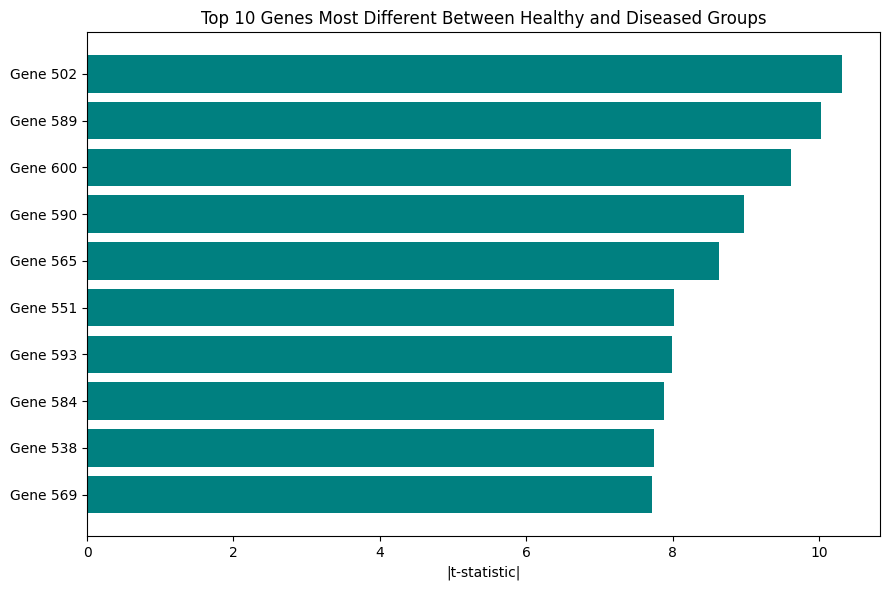

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_plot = top10_genes.sort_values('abs_t')
ax.barh([f'Gene {g}' for g in top10_plot['gene']], top10_plot['abs_t'], color='teal')
ax.set_xlabel('|t-statistic|')
ax.set_title('Top 10 Genes Most Different Between Healthy and Diseased Groups')
plt.tight_layout()
plt.savefig('top10_genes.png', dpi=150)
plt.show()

**Conclusion:** Genes 502, 589, and 600 show the largest absolute t-statistics (all with extremely small p-values, well below any reasonable significance threshold even after accounting for multiple testing), making them the strongest candidates for genes that differ most between the healthy and diseased groups. This t-test-based ranking directly answers the collaborator's question and could be used as a starting point for further biological investigation into which genes are most associated with the disease.